# Customer Segmentation using RFM Analysis

## Objective

The objective of this project is to segment customers based on purchasing behavior using the RFM (Recency, Frequency, Monetary) framework.

The resulting customer segments can help businesses improve customer retention, personalize marketing campaigns, and identify high-value customers.

Dataset:
- Olist Brazilian E-Commerce Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cust = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_customers_dataset.csv')
orders = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_orders_dataset.csv')
payment = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_order_payments_dataset.csv')

## Dataset Description

This project uses three datasets:

- Customers
- Orders
- Payments

These tables are merged to calculate Recency, Frequency and Monetary metrics for every unique customer.

# Preparing the Dataset And Doing Basic Steps

In [3]:
cust.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [4]:
orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [5]:
payment.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [10]:
# Merging The Tables Together

df1 = orders.merge(cust[['customer_id','customer_unique_id']], how = 'inner', on = 'customer_id')
df = df1.merge(payment[['order_id','payment_value']], how = 'inner', on = 'order_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,179.12


In [11]:
# Dropping Unwanted Columns
df.drop(columns = ['order_status','order_approved_at','order_delivered_carrier_date',
                   'order_delivered_customer_date','order_estimated_delivery_date'], inplace = True)
df.head(2)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2.00


In [13]:
df.isna().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
customer_unique_id          0
payment_value               0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  103886 non-null  object 
 1   customer_id               103886 non-null  object 
 2   order_purchase_timestamp  103886 non-null  object 
 3   customer_unique_id        103886 non-null  object 
 4   payment_value             103886 non-null  float64
dtypes: float64(1), object(4)
memory usage: 4.0+ MB


In [15]:
df.describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [16]:
df.shape

(103886, 5)

### First Thing We Need To Do Is Calculate The Total Payment For Each Order

In [22]:
order_summary = df.groupby('order_id')['payment_value'].sum().reset_index()
order_summary.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [24]:
# Now our df has duplictae rows if we consider :'order_id','customer_unique_id','order_purchase_timestamp'.
# But we need only one row per order right now, so we will remove duplicates

order_info = df[['order_id','customer_unique_id','order_purchase_timestamp']].drop_duplicates()

### Creating The Base Table For RFM

In [26]:
rfm_df = order_info.merge(order_summary, how = 'inner', on = 'order_id')
rfm_df.head()

,order_id,customer_unique_id,order_purchase_timestamp,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,28.62


In [31]:
# Converting order_purchase_timestamp to datetime
rfm_df['order_purchase_timestamp'] = pd.to_datetime(rfm_df['order_purchase_timestamp'])

In [33]:
last_purchase_date = rfm_df['order_purchase_timestamp'].max()
last_purchase_date

Timestamp('2018-10-17 17:30:18')

In [37]:
last_purchase = rfm_df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
last_purchase.head()

,customer_unique_id,order_purchase_timestamp
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [39]:
analysis_date = last_purchase_date + pd.Timedelta(days = 1 )
analysis_date

Timestamp('2018-10-18 17:30:18')

In [44]:
last_purchase['recency'] = (analysis_date - last_purchase['order_purchase_timestamp']).dt.days
last_purchase.head()

,customer_unique_id,order_purchase_timestamp,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,164
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,586
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,370
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,337



## Calculating Recency

Recency measures how recently a customer made their last purchase.
Lower recency indicates more recent activity.

In [47]:
recency_df = last_purchase[['customer_unique_id','recency']]
recency_df.head()

,customer_unique_id,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164
2,0000f46a3911fa3c0805444483337064,586
3,0000f6ccb0745a6a4b88665a16c9f078,370
4,0004aac84e0df4da2b147fca70cf8255,337



## Calculating Frequency

Frequency measures the number of unique purchases made by each customer.

In [56]:
frequency_df = rfm_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequency_df.rename(columns = {'order_id':'freq'} , inplace = True)
frequency_df.head()

,customer_unique_id,freq
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1



## Calculating Monetary

Monetary measures the total amount spent by each customer.

In [57]:
monetary_df = rfm_df.groupby('customer_unique_id')['payment_value'].sum().reset_index()
monetary_df.rename(columns = {'payment_value':'monetary'}, inplace = True)
monetary_df.head()

,customer_unique_id,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89



# Creating RFM Table

In [58]:
rfm = recency_df.merge(frequency_df, how = 'inner', on = 'customer_unique_id')
rfm = rfm.merge(monetary_df, how = 'inner', on = 'customer_unique_id')
rfm.head()

,customer_unique_id,recency,freq,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [62]:
rfm['r_score'] = pd.qcut(rfm['recency'], q = 5, labels = [5,4,3,2,1])
rfm['m_score'] = pd.qcut(rfm['monetary'], q = 5, labels  = [1,2,3,4,5])

rfm.head()

,customer_unique_id,recency,freq,monetary,r_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,4


In [64]:
# In our previous cohort analysis, we found out that only 97% customers bought once. so it is impossible for qcut
# to split data into 5 quantiles evenly. Therfore, we need a different approach for it

def freq_score(freq):
    if freq == 1:
        return 1
    elif freq == 2:
        return 2
    elif freq == 3:
        return 3
    elif freq<=5:
        return 4
    else:
        return 5

rfm['f_score'] = rfm['freq'].apply(freq_score)

rfm.head()

,customer_unique_id,recency,freq,monetary,r_score,m_score,f_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,4,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,2,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,4,1


In [67]:
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['total_score'] = rfm['r_score'].astype(int) + rfm['f_score'].astype(int) + rfm['m_score'].astype(int)

rfm.head()

,customer_unique_id,recency,freq,monetary,r_score,m_score,f_score,rfm_score,total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,4,1,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,2,1,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,4,1,214,7


In [68]:
def customer_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
        
    elif r >= 4 and f >= 3 and m >= 3:
        return 'Loyal Customer'

    elif r >= 4 and f <= 2:
        return 'Potential Loyalist'

    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk High Value'

    elif r <= 2 and f >= 4:
        return 'At Risk'

    elif r <= 2 and f <= 2:
        return 'Lost'

    else:
        return 'Others'

rfm['segment'] = rfm.apply(customer_segment, axis = 1)

rfm.head()

,customer_unique_id,recency,freq,monetary,r_score,m_score,f_score,rfm_score,total_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,4,1,414,9,Potential Loyalist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,6,Potential Loyalist
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,2,1,112,4,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,4,Lost
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,4,1,214,7,Lost


In [69]:
rfm['segment'].value_counts()

segment
Potential Loyalist    38481
Lost                  38355
Others                19108
Loyal Customer          108
Champions                34
At Risk High Value        6
At Risk                   3
Name: count, dtype: int64

In [70]:
rfm['segment'].value_counts(normalize = True).mul(100).round(2)

segment
Potential Loyalist    40.04
Lost                  39.91
Others                19.88
Loyal Customer         0.11
Champions              0.04
At Risk High Value     0.01
At Risk                0.00
Name: proportion, dtype: float64

## Customer Segmentation Results

The RFM analysis grouped customers into business-oriented segments based on their
Recency, Frequency, and Monetary scores. Due to the highly skewed purchase
behavior in the dataset (most customers purchased only once), the resulting
segment distribution is also highly imbalanced.


# Plotting Visuals 

## Customer Distribution By Segment

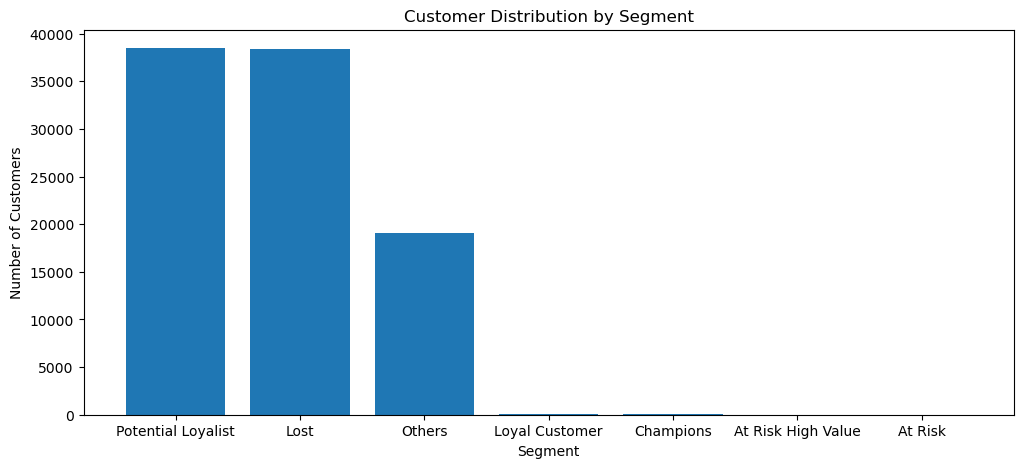

In [147]:
segment_counts = rfm['segment'].value_counts()

plt.figure(figsize = (12,5))
plt.bar(segment_counts.index , segment_counts.values)
plt.title('Customer Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.savefig("Customer Distribution by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

## Revenue Contribution By Segment

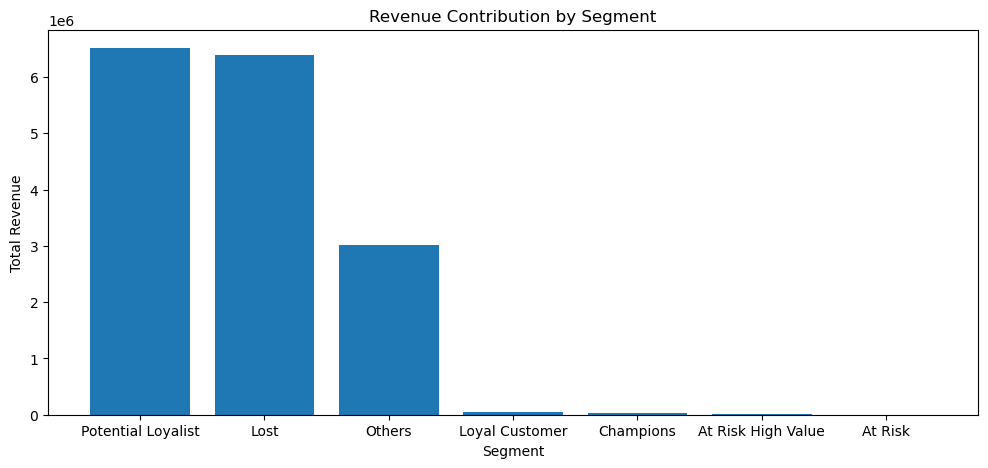

In [139]:
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending = False)

plt.figure(figsize = (12,5))
plt.bar(segment_revenue.index, segment_revenue.values)
plt.title('Revenue Contribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Revenue')
plt.savefig("Revenue Contribution by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

## Average Monetary Value By Segment

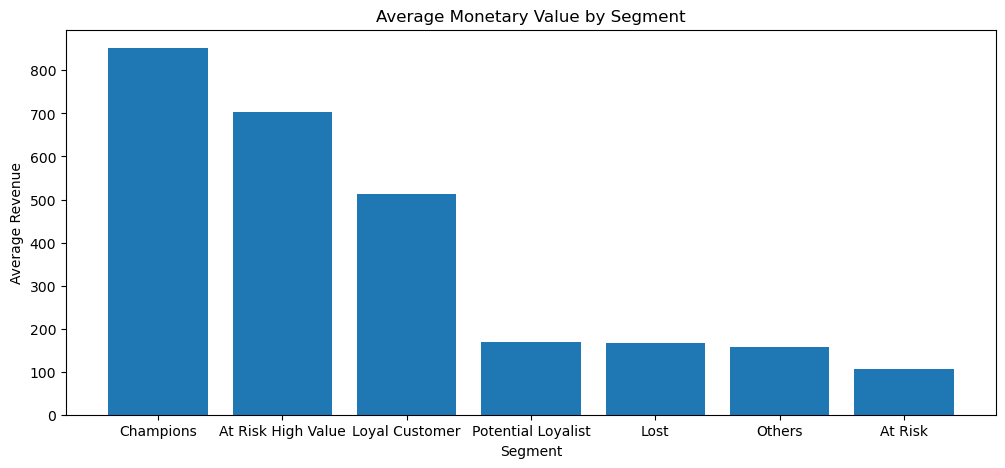

In [140]:
avg_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending = False)

plt.figure(figsize = (12,5))
plt.bar(avg_monetary.index, avg_monetary.values)
plt.title('Average Monetary Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Revenue')
plt.savefig ("Average Monetary Value by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

## Average Recency By Segment

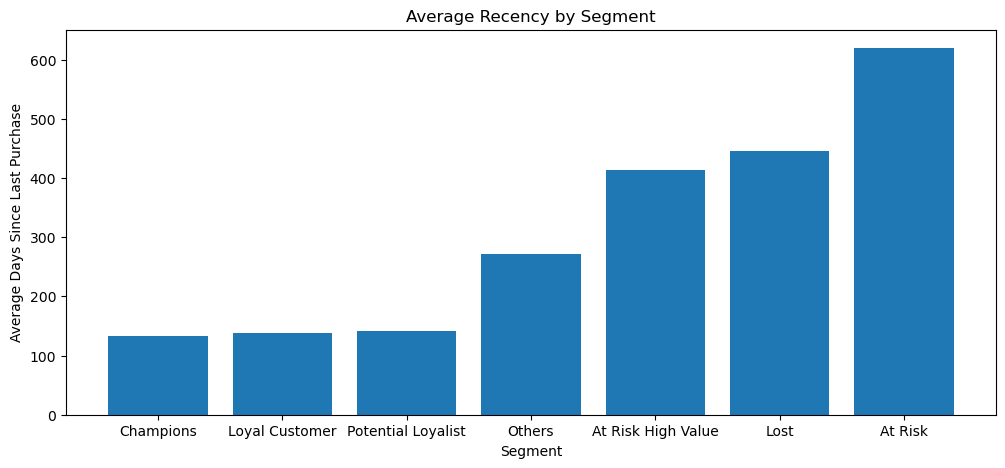

In [141]:
avg_recency = rfm.groupby('segment')['recency'].mean().sort_values()

plt.figure(figsize = (12,5))
plt.bar(avg_recency.index, avg_recency.values)
plt.title('Average Recency by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Days Since Last Purchase')
plt.savefig("Average Recency by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

## Average Frequency By Segment

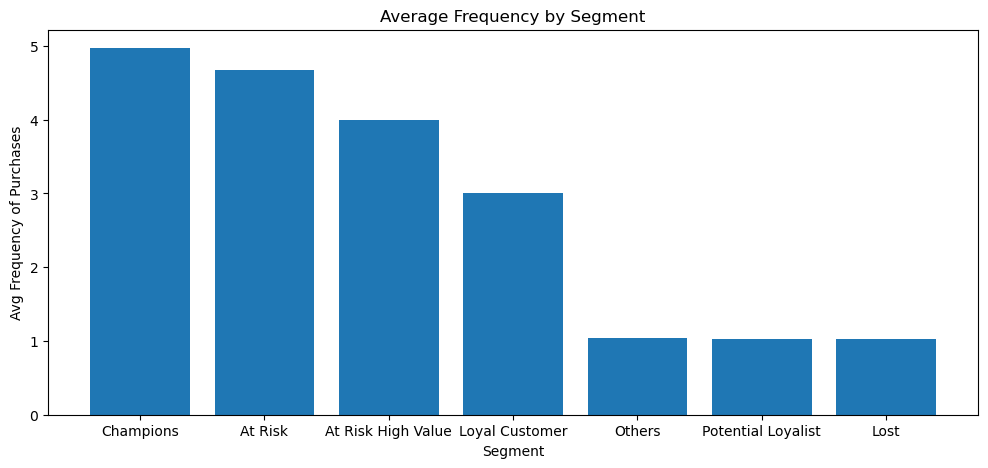

In [142]:
avg_freq = rfm.groupby('segment')['freq'].mean().sort_values(ascending = False)

plt.figure(figsize = (12,5))
plt.bar(avg_freq.index, avg_freq.values)
plt.title('Average Frequency by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Frequency of Purchases')
plt.savefig("Average Frequency by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [132]:
# Exporting RFM As CSV
rfm.to_csv("rfm_customer_segments.csv", index=False)

# Conclusion

This RFM analysis segmented customers based on their purchasing behavior using Recency, Frequency, and Monetary metrics.

    
## Key Insights

- Around **40% of customers** fall into the **Potential Loyalist** segment. These customers have purchased recently but have made only a single purchase, making them ideal candidates for retention campaigns.

- Nearly **40% of customers** belong to the **Lost** segment, indicating a significant number of customers did not return after their initial purchase.

- **Champions** and **Loyal Customers** represent a very small portion of the customer base but generate the highest average revenue and purchase frequency.

- The segment distribution confirms the findings from the earlier cohort analysis, where approximately **97% of customers made only one purchase**, resulting in a highly skewed customer base.

- Customers with higher purchase frequency consistently contribute significantly more revenue than one-time purchasers.

# Business Recommendations

Based on the analysis, the following actions are recommended:

### Potential Loyalists
- Encourage a second purchase through personalized email campaigns and limited-time discounts.
- Introduce loyalty rewards after the second purchase.

### Lost Customers
- Launch win-back campaigns with targeted promotions.
- Identify common reasons for customer churn and improve the post-purchase experience.

### Champions
- Provide exclusive benefits such as VIP memberships, early product access, and referral incentives.
- Use these customers to promote brand advocacy.

### At Risk High Value Customers
- Prioritize retention through personalized offers and proactive customer support.
- Re-engage them before they transition into the Lost segment.

### Overall
- Focus business efforts on converting first-time buyers into repeat customers, as repeat purchases have the greatest impact on long-term customer value.

# Final Takeaway

The RFM framework provides a simple yet powerful approach for identifying customer value and prioritizing marketing strategies. By combining recency, purchase frequency, and spending behavior, businesses can allocate resources more effectively, improve customer retention, and maximize long-term revenue.